# **TUGAS PRAKTIKUM MANDIRI**

In [9]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", path)

100%|██████████| 286k/286k [00:00<00:00, 614kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1


In [14]:
# 1. Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm

# 2. Load dataset
path = "/content/gdrive/MyDrive/Semester_7/praktikum_ml/praktikum03/data/archive/day.csv"
df = pd.read_csv(path)

In [16]:
# 3. Tampilkan informasi umum
print("===================== Informasi Dataset =====================")
print(df.info())
print("\n===================== 5 Data Teratas =====================")
print(df.head())
print("\n===================== Statistik Deskriptif =====================")
print(df.describe())

===================== Informasi Dataset =====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

===================== 5 D

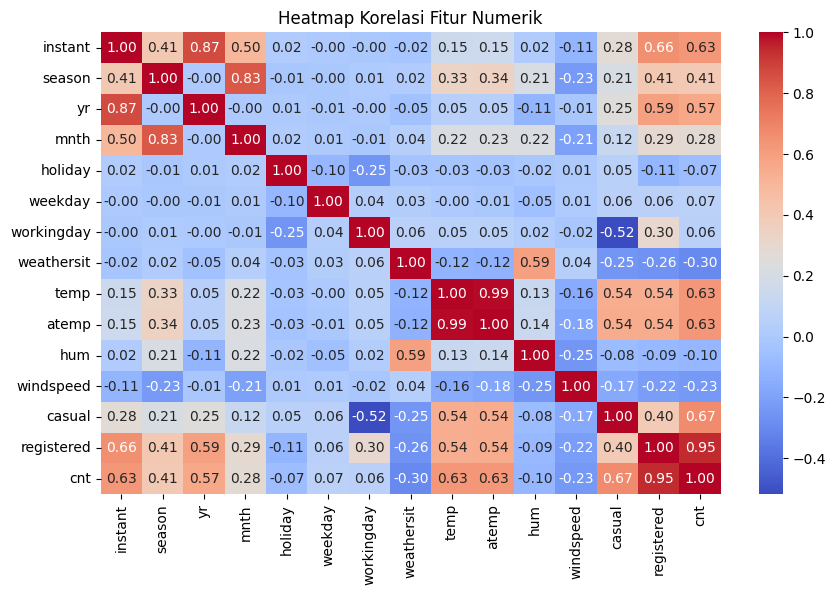

In [31]:
# 4. Analisis Korelasi (untuk memilih variabel independen)
plt.figure(figsize=(10, 6))

# hanya ambil kolom numerik agar tidak error
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()


In [23]:
# 5. Pilih variabel X (independen) dan Y (dependen)
# Y = cnt (total count)
# X = beberapa variabel relevan berdasarkan korelasi tinggi dengan cnt
# contoh: temp, atemp, hum, windspeed, season, yr, mnth, holiday, workingday, weathersit

X = df[['temp', 'atemp', 'hum', 'windspeed', 'season', 'yr', 'mnth', 'holiday', 'workingday', 'weathersit']]
y = df['cnt']

In [21]:
# 6. Split data train dan test (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# 7. Modeling menggunakan OLS (statsmodels)
X_train_sm = sm.add_constant(X_train)  # tambah konstanta
model_ols = sm.OLS(y_train, X_train_sm).fit()
print("\n=== Hasil Model OLS ===")
print(model_ols.summary())


=== Hasil Model OLS ===
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     209.6
Date:                Tue, 07 Oct 2025   Prob (F-statistic):          4.18e-184
Time:                        14:32:02   Log-Likelihood:                -4792.9
No. Observations:                 584   AIC:                             9608.
Df Residuals:                     573   BIC:                             9656.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1528.1555    26

In [24]:
# 8. Prediksi dan evaluasi model
X_test_sm = sm.add_constant(X_test)
y_pred = model_ols.predict(X_test_sm)

# Hitung metrik evaluasi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== Evaluasi Model ===")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.3f}")


=== Evaluasi Model ===
MAE : 622.19
MSE : 698476.41
RMSE: 835.75
R² Score: 0.826


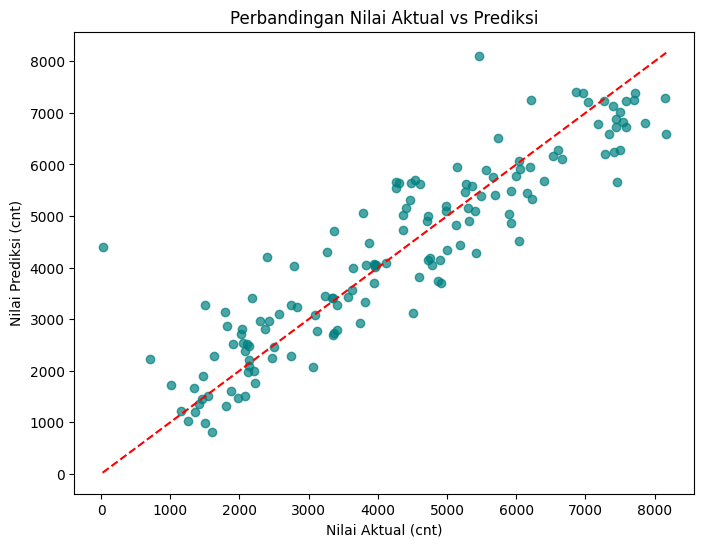

In [25]:
# 9. Visualisasi Prediksi vs Aktual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.xlabel("Nilai Aktual (cnt)")
plt.ylabel("Nilai Prediksi (cnt)")
plt.title("Perbandingan Nilai Aktual vs Prediksi")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [26]:
# 10. Tabel hasil prediksi
hasil = pd.DataFrame({
    "Aktual (cnt)": y_test,
    "Prediksi (cnt)": y_pred,
    "Selisih (cnt)": y_test - y_pred
})
print("\n=== Contoh Hasil Prediksi ===")
print(hasil.head(10))


=== Contoh Hasil Prediksi ===
     Aktual (cnt)  Prediksi (cnt)  Selisih (cnt)
703          6606     6273.731244     332.268756
33           1550     1514.266200      35.733800
300          3747     2922.745496     824.254504
456          6041     4524.335546    1516.664454
633          7538     6825.688115     712.311885
557          7264     7233.931564      30.068436
39           1605      809.519721     795.480279
356          2209     1992.955667     216.044333
559          7499     7015.809949     483.190051
514          5743     6512.347927    -769.347927
